In [1]:
from GradientGang.PreProcessing import PreProcessor
%load_ext autoreload
%autoreload 2

In [2]:
params_path = "params/preprocessing_params_global_features.yaml"
params_path

'params/preprocessing_params_global_features.yaml'

In [3]:
preprocessing = PreProcessor.fromYAML(params_path)

Data loaded successfully.
Last column removed successfully.
Inspirate features handled successfully.
Selected sample indices: [0, 1, 2]


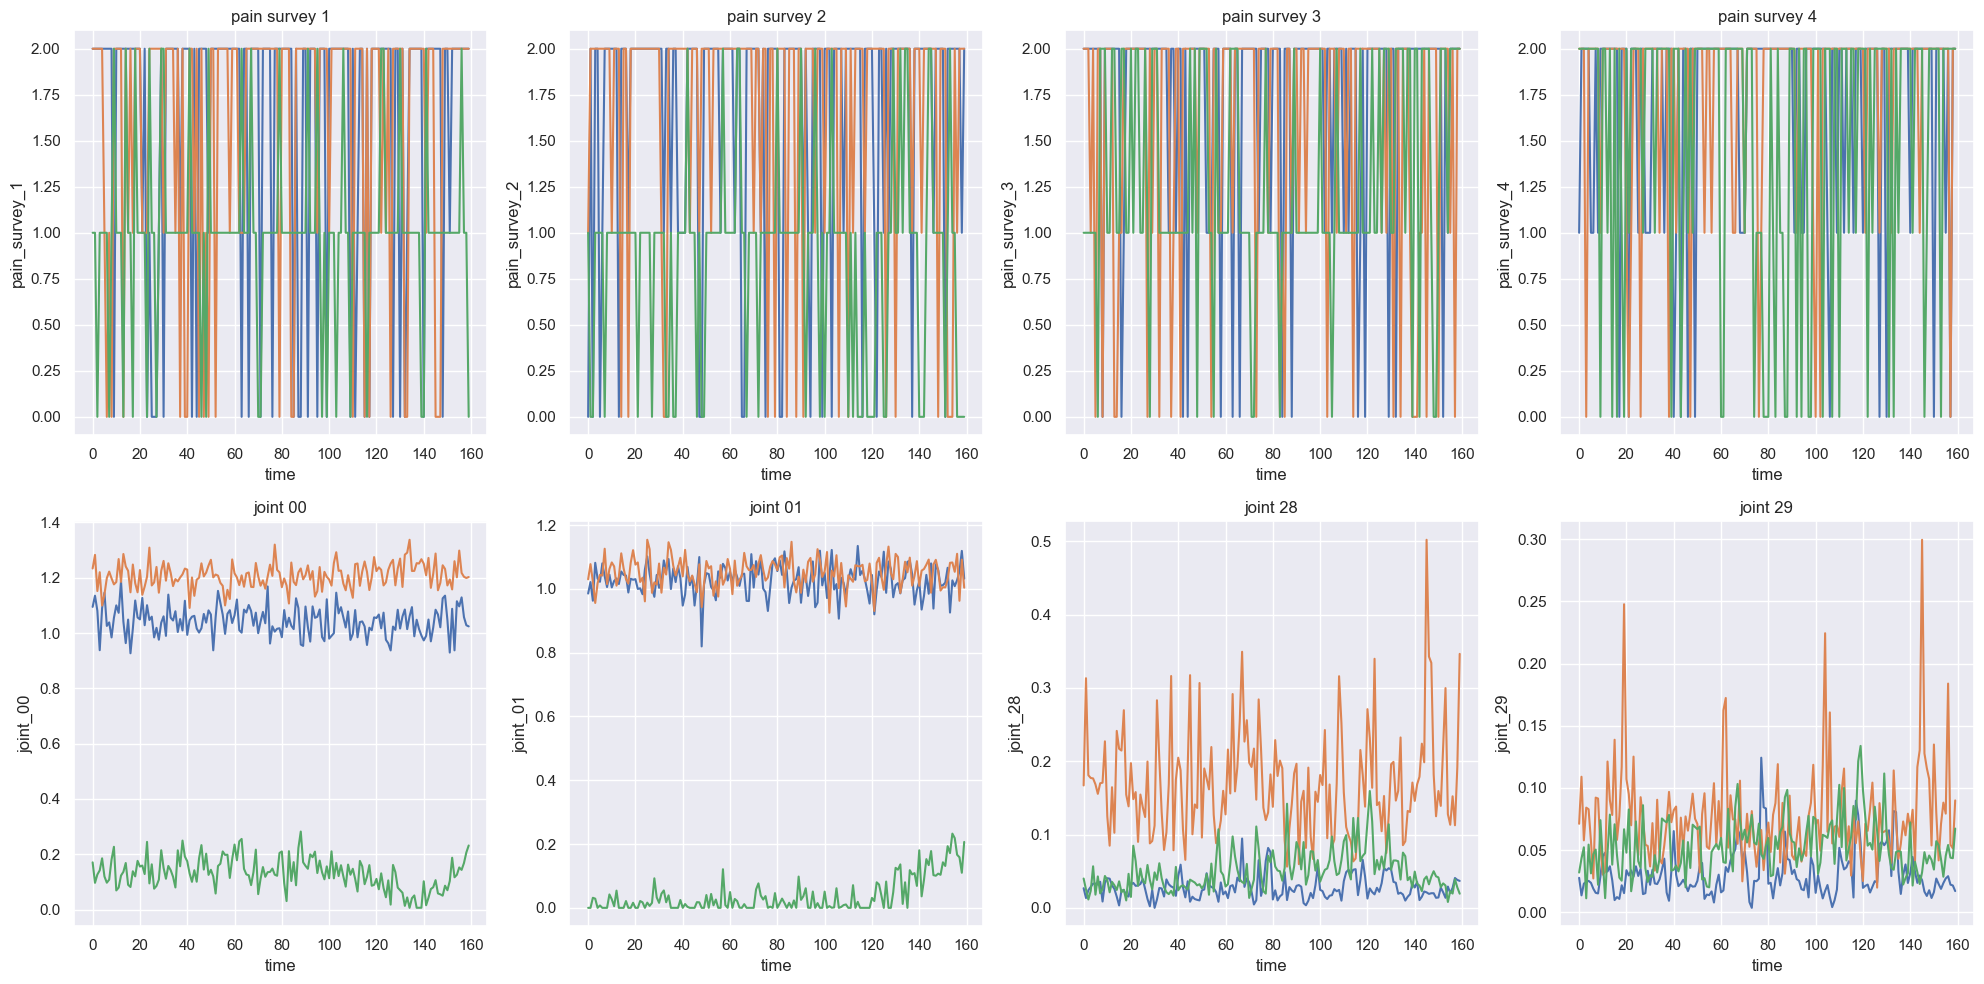

Data normalized successfully.
Selected sample indices: [0, 1, 2]


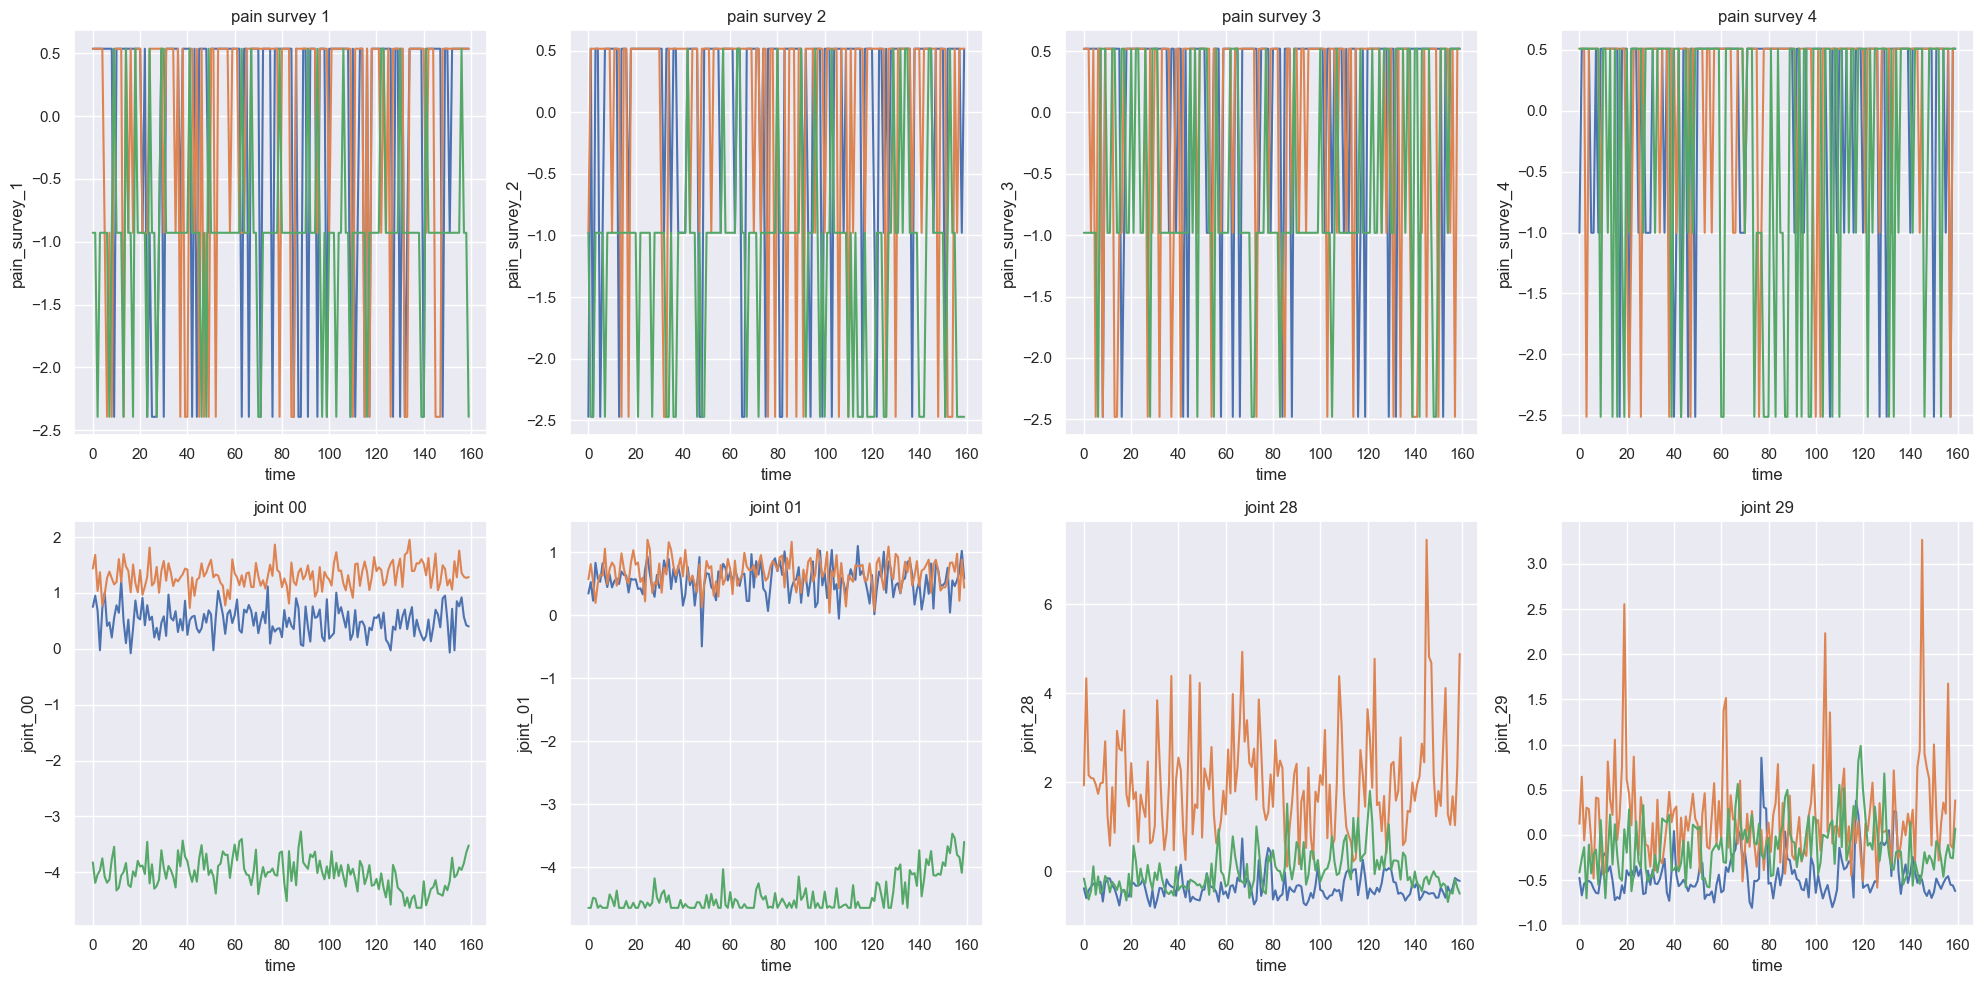

Global features extracted successfully.
  - Training: 310 features from 661 samples
  - Test: 310 features from 1324 samples


Applying PCA:   0%|          | 0/34 [00:00<?, ?it/s]

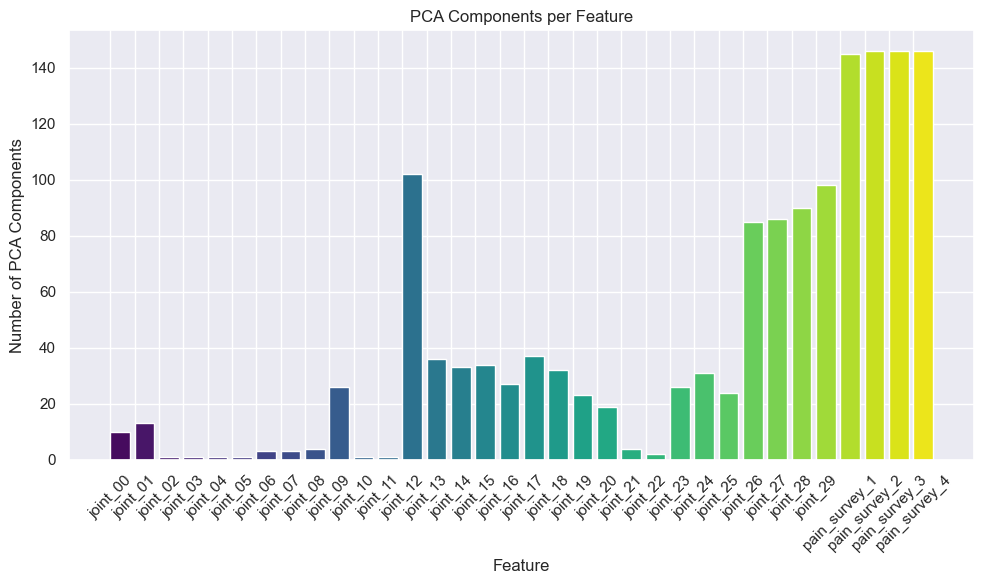

POD (PCA) applied successfully.
  - POD components: 1437

Applying feature selection to global features...

Feature Selection: all_three_intersection
Input features: 1747
  Variance threshold: 1747 → 1668 features
  Correlation filtering: 1668 → 1556 features
  Training RandomForest for feature selection...
  RandomForest selected top 300 features
  Calculating Mutual Information scores...
  Mutual Information selected top 300 features
  Training Lasso for feature selection...
  Lasso selected 240 non-zero features

✓ Feature selection completed
  Final selected features: 31
  Reduction: 1747 → 31 (98.2% reduction)

✓ Saved 31 selected features to ../dataset/PirateProcessed\selected_features.txt
Fourier features added successfully.
Global features saved successfully.
  - Total global features: 32
Data saved successfully.


In [4]:
preprocessing.preprocess()

In [5]:
# Check if preprocessing will save to the correct location
print(f"Raw data path: {preprocessing.path_raw_data}")
print(f"Processed data path: {preprocessing.path_processed_data}")
print(f"Train file name: {preprocessing.name_train_file}")
print(f"\nWill load from: {preprocessing.path_raw_data}/{preprocessing.name_train_file}")
print(f"Will save to: {preprocessing.path_processed_data}/{preprocessing.name_train_file}")


Raw data path: ../dataset/Pirate
Processed data path: ../dataset/PirateProcessed
Train file name: pirate_pain_train.csv

Will load from: ../dataset/Pirate/pirate_pain_train.csv
Will save to: ../dataset/PirateProcessed/pirate_pain_train.csv


In [6]:
trainData = preprocessing.load_data("../PirateProcessed/pirate_pain_train.csv")

In [7]:
trainData.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_26,joint_27,joint_28,joint_29,sin_1.0,cos_1.0,sin_0.1,cos_0.1,sin_0.01,cos_0.01
0,0,0,0.536696,-2.471259,0.519553,-1.001721,0.750358,0.345765,0.808533,0.806095,...,-0.403239,-0.560471,-0.379913,-0.474647,0.000000e+00,1.0,0.000000,1.000000,0.000000,1.000000
1,0,1,0.536696,0.515426,0.519553,0.508866,0.950692,0.527408,0.727484,0.945659,...,-0.473561,-0.729701,-0.600752,-0.668851,-2.449294e-16,1.0,0.587785,0.809017,0.062791,0.998027
2,0,2,0.536696,-2.471259,0.519553,0.508866,0.681264,0.232215,0.779053,0.695665,...,-0.425906,-0.628091,-0.424353,-0.539520,-4.898587e-16,1.0,0.951057,0.309017,0.125333,0.992115
3,0,3,0.536696,0.515426,0.519553,0.508866,-0.025133,0.833153,0.739923,0.729290,...,-0.498782,-0.636364,-0.350040,-0.518263,-7.347881e-16,1.0,0.951057,-0.309017,0.187381,0.982287
4,0,4,0.536696,0.515426,0.519553,0.508866,0.727986,0.582922,0.776084,0.650746,...,-0.606111,-0.697985,-0.277425,-0.508900,-9.797174e-16,1.0,0.587785,-0.809017,0.248690,0.968583


In [8]:
trainLabels = preprocessing.load_data("../PirateProcessed/pirate_pain_train_labels.csv")
trainLabels.head()

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,low_pain
3,3,no_pain
4,4,no_pain


In [9]:
# Check data shapes to understand the mismatch
print(f"Train Data shape: {trainData.shape}")
print(f"Train Labels shape: {trainLabels.shape}")

Train Data shape: (105760, 42)
Train Labels shape: (661, 2)


Aggregated Train Data shape: (661, 40)
Train Labels shape: (661,)


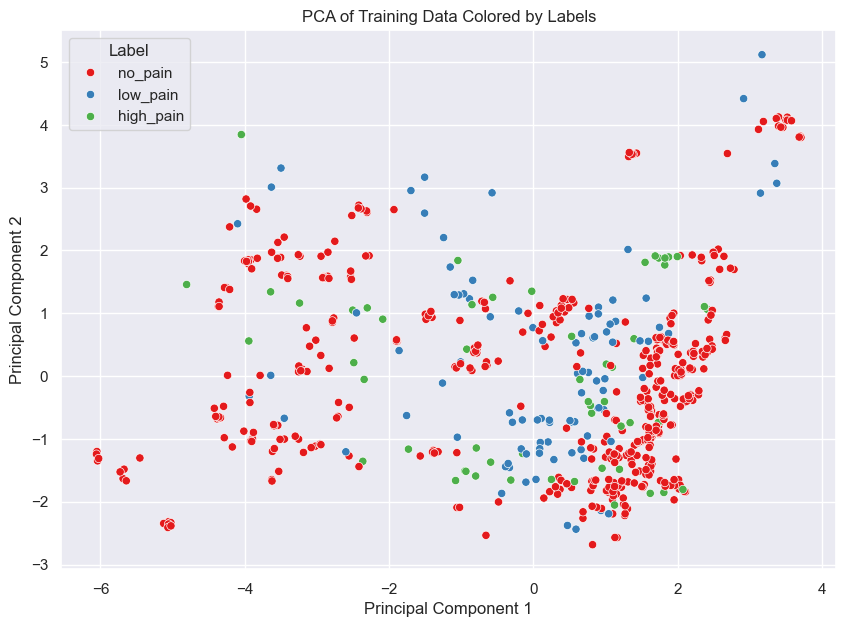

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
sns.set_theme()

# Aggregate time series data by sample_index (take mean across time)
if 'sample_index' in trainData.columns:
    # Group by sample_index and take mean of all numeric columns
    trainDataAgg = trainData.groupby('sample_index').mean(numeric_only=True)
    # Remove time column if it exists
    if 'time' in trainDataAgg.columns:
        trainDataAgg = trainDataAgg.drop(columns=['time'])
    trainDataNp = trainDataAgg.to_numpy()
    print(f"Aggregated Train Data shape: {trainDataNp.shape}")
else:
    trainDataNp = trainData.to_numpy()

trainLabelsNp = trainLabels["label"].to_numpy()
print(f"Train Labels shape: {trainLabelsNp.shape}")

# Plot first 2 principal components colored by label
pca = PCA(n_components=2)
trainDataPca = pca.fit_transform(trainDataNp)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=trainDataPca[:, 0], y=trainDataPca[:, 1], hue=trainLabelsNp, palette="Set1")
plt.title("PCA of Training Data Colored by Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Label", loc="best")
plt.show()


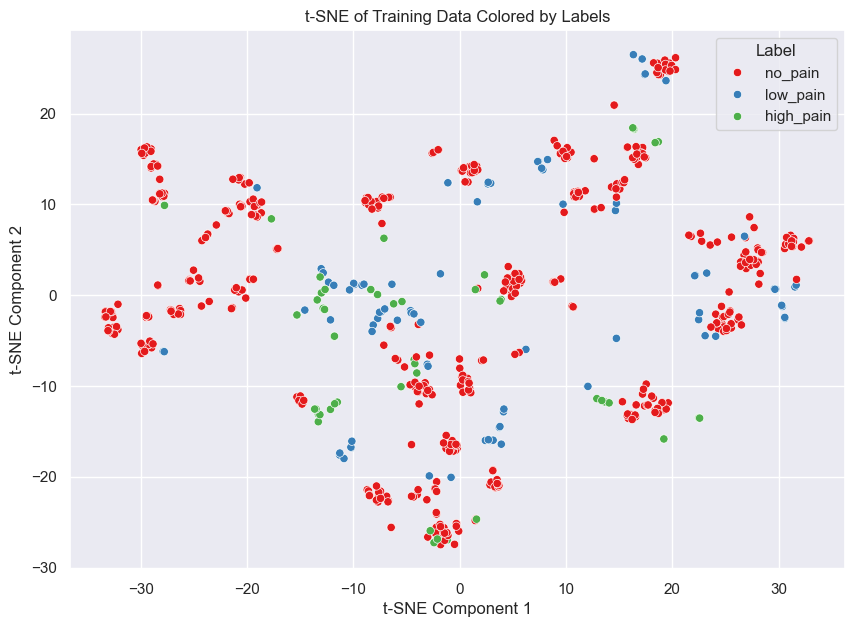

In [11]:
# Plot tsne colored by label
from sklearn.manifold import TSNE

# Use the aggregated data from previous cell
tsne = TSNE(n_components=2, random_state=42)
trainDataTsne = tsne.fit_transform(trainDataNp)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=trainDataTsne[:, 0], y=trainDataTsne[:, 1], hue=trainLabelsNp, palette="Set1")
plt.title("t-SNE of Training Data Colored by Labels")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Label", loc="best")
plt.show()


## 🚀 Next Steps After Preprocessing

### ✅ If verification passed:
Your data is properly preprocessed! Now you can:

1. **Go back to your training pipeline** (FinalPipelineTest.ipynb)
2. **Re-run training** with the newly preprocessed data
3. **Expected result:** Test F1 should improve from 0.91 → ~0.94-0.95

### ⚠️ If verification failed:
Re-run cell 4 (`preprocessing.preprocess()`) to ensure both train and test are normalized together.

---

## 📊 What the PreProcessor does:

The `normalize_per_process()` method in PreProcessor:
```python
# Calculate mean and std from TRAINING data
mean = training_data[col].mean()
std = training_data[col].std()

# Apply to BOTH train and test
training_data[col] = (training_data[col] - mean) / std
test_data[col] = (test_data[col] - mean) / std  # Uses TRAINING stats!
```

This ensures test data is normalized using training statistics, which is critical for model performance!